In [8]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

In [12]:

file_path = '/content/drive/MyDrive/Colab Notebooks/TSLA.csv'
data = pd.read_csv(file_path)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0363
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0237
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0169
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0126
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0099
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0083
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0073
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0066
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0062
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0058
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0055
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0053
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0051
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0048
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0046
Epoc

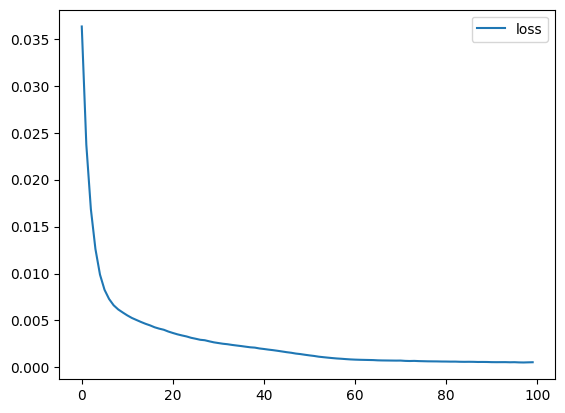

In [21]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt

# [유지] 데이터 분리 함수
def make_sample(data, window):
    train = []
    target = []
    for i in range (len(data)-window):
        train.append(data[i:i+window])
        target.append(data[i+window])
    return np.array(train), np.array(target)

# [유지] 1000개의 사인파 데이터 생성 루프
seq_data = []
for i in np.arange(0, 1000):
    seq_data += [[np.sin(np.pi * i *0.01)]]

# -------------------------------------------------------------
# [수정 지점] 아래 코드들을 for문 밖으로 꺼내어 들여쓰기를 정렬했습니다.
# -------------------------------------------------------------

# [유지] 데이터셋 생성 (윈도우 크기 5)
X, y = make_sample(seq_data, 5)

# [유지] SimpleRNN 모델 구성
model = Sequential()
model.add(SimpleRNN(5, activation='tanh', input_shape=(5, 1)))
model.add(Dense(1, activation='tanh'))

# [유지] 컴파일 및 학습
model.compile(optimizer='adam', loss='mse')
history = model.fit(X, y, epochs=100, verbose=1)

# [유지] 학습 Loss 추이 시각화
plt.plot(history.history['loss'], label="loss")
plt.legend()
plt.show()

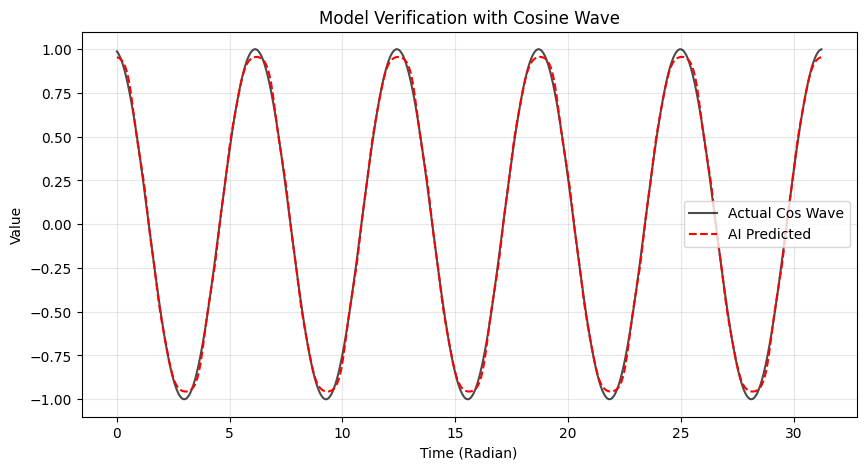

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 새로운 코사인 데이터 생성 (내용 유지)
seq_data = []
for i in np.arange(0, 1000):
    seq_data += [[np.cos(np.pi * i * 0.01)]]

# 2. 데이터 분리 (윈도우 크기 5)
X, y = make_sample(seq_data, 5)

# 3. 모델 예측 (verbose=0 유지)
y_pred = model.predict(X, verbose=0)

# -------------------------------------------------------------
# [수정 지점] x축의 범위를 데이터 개수(995개)에 정확히 맞추었습니다.
# 전체 1000개 데이터 - 윈도우 크기 5 = 총 995개의 샘플이 존재합니다.
# -------------------------------------------------------------
time_axis = np.pi * np.arange(0, 995) * 0.01

# 4. 실제 정답(시리즈)과 AI 예측 결과 시각화
plt.figure(figsize=(10, 5))
plt.plot(time_axis, y, label="Actual Cos Wave", color="black", alpha=0.7)
plt.plot(time_axis, y_pred, label="AI Predicted", color="red", linestyle="--")

plt.title("Model Verification with Cosine Wave")
plt.xlabel("Time (Radian)")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5.3126e-04
Epoch 2/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1211e-04
Epoch 3/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2830e-04
Epoch 4/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1083e-04
Epoch 5/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0353e-04
Epoch 6/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0970e-04
Epoch 7/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3849e-04
Epoch 8/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0805e-04
Epoch 9/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1054e-04
Epoch 10/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0459e-04
Epoch 11/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1005e-04
Epoch 12/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.1935e-04
Epoch 13/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0849e-04
Epoch 14/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0552e-04
Epoch 15/50


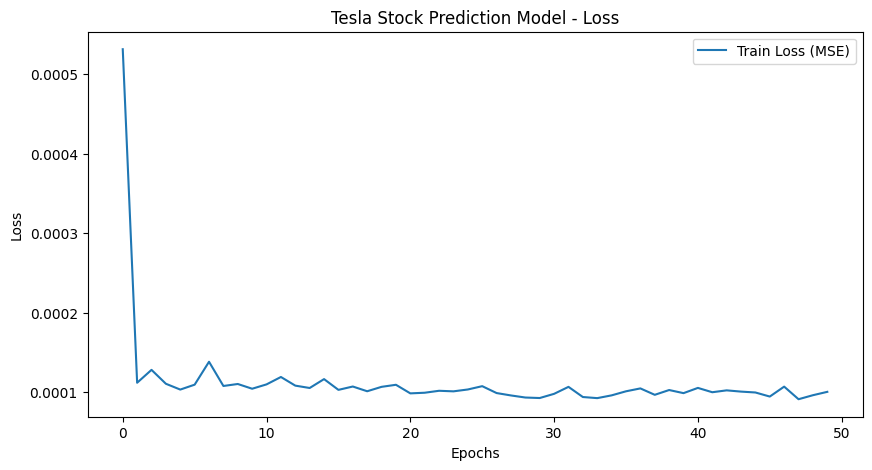

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


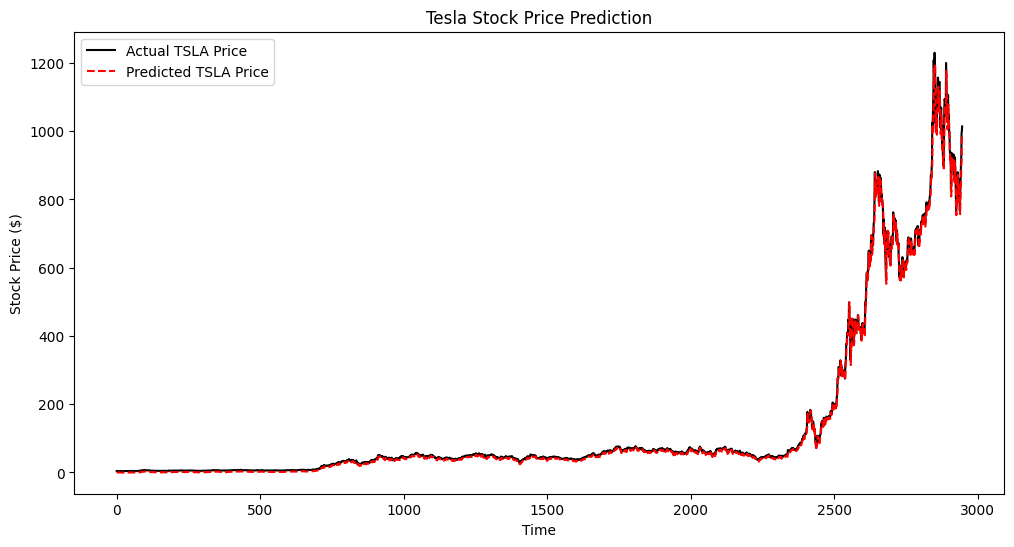

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt

# 1. 구글 드라이브 마운트 확인 및 데이터 불러오기
# (코랩 왼쪽 파일 메뉴에서 드라이브 마운트 버튼을 누르거나 아래 주석을 해제하세요)
# from google.colab import drive
# drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Colab Notebooks/TSLA.csv'

# CSV 파일 로드 (주가 데이터 확인)
df = pd.read_csv(file_path)

# 일반적으로 주가 예측에는 '종가(Close)' 데이터를 가장 많이 활용합니다.
# 데이터프레임의 열 이름이 대소문자(Close 또는 close)일 수 있으니 확인이 필요합니다.
data = df['Close'].values.reshape(-1, 1)

# 2. 데이터 전처리: 0~1 사이로 스케일링 (주가 데이터 필수 과정)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# 3. 시계열 샘플 데이터를 만드는 함수 정의
def make_sample(data, window):
    train = []
    target = []
    for i in range(len(data) - window):
        train.append(data[i:i+window])
        target.append(data[i+window])
    return np.array(train), np.array(target)

# 4. 데이터셋 생성 (과거 5일치 데이터를 보고 다음 날 종가를 예측)
WINDOW_SIZE = 10
X, y = make_sample(scaled_data, WINDOW_SIZE)

# 5. SimpleRNN 모델 설계 (주가 변동성에 맞춰 tanh 활성화 함수 유지)
model = Sequential()
model.add(SimpleRNN(16, activation='tanh', input_shape=(WINDOW_SIZE, 1)))
model.add(Dense(1)) # 다음 날 주가 '값' 자체를 예측하므로 활성화 함수를 비웁니다.

# 6. 모델 컴파일
model.compile(optimizer='adam', loss='mse')

# 7. 모델 학습
history = model.fit(X, y, epochs=50, batch_size=16, verbose=1)

# 8. 학습 손실(Loss) 시각화
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label="Train Loss (MSE)")
plt.title("Tesla Stock Prediction Model - Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 9. 예측 결과 시각화 (실제 주가 vs 모델 예측 주가)
predicted_scaled = model.predict(X)
# 0~1로 압축했던 데이터를 다시 원래 달러($) 가격으로 되돌립니다.
predicted_prices = scaler.inverse_transform(predicted_scaled)
actual_prices = scaler.inverse_transform(y)

plt.figure(figsize=(12, 6))
plt.plot(actual_prices, label="Actual TSLA Price", color='black')
plt.plot(predicted_prices, label="Predicted TSLA Price", color='red', linestyle='--')
plt.title("Tesla Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Stock Price ($)")
plt.legend()
plt.show()

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 1.7796e-05
Epoch 2/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4.0463e-06
Epoch 3/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.5725e-06
Epoch 4/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.6693e-06
Epoch 5/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.4780e-06
Epoch 6/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.9126e-06
Epoch 7/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.1413e-06
Epoch 8/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.7291e-06
Epoch 9/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.7844e-06
Epoch 10/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.6709e-06
Epoch 11/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5346e-06
Epoch 12/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6518e-06
Epoch 13/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8509e-06
Epoch 14/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.4777e-06
Epoch 15/50


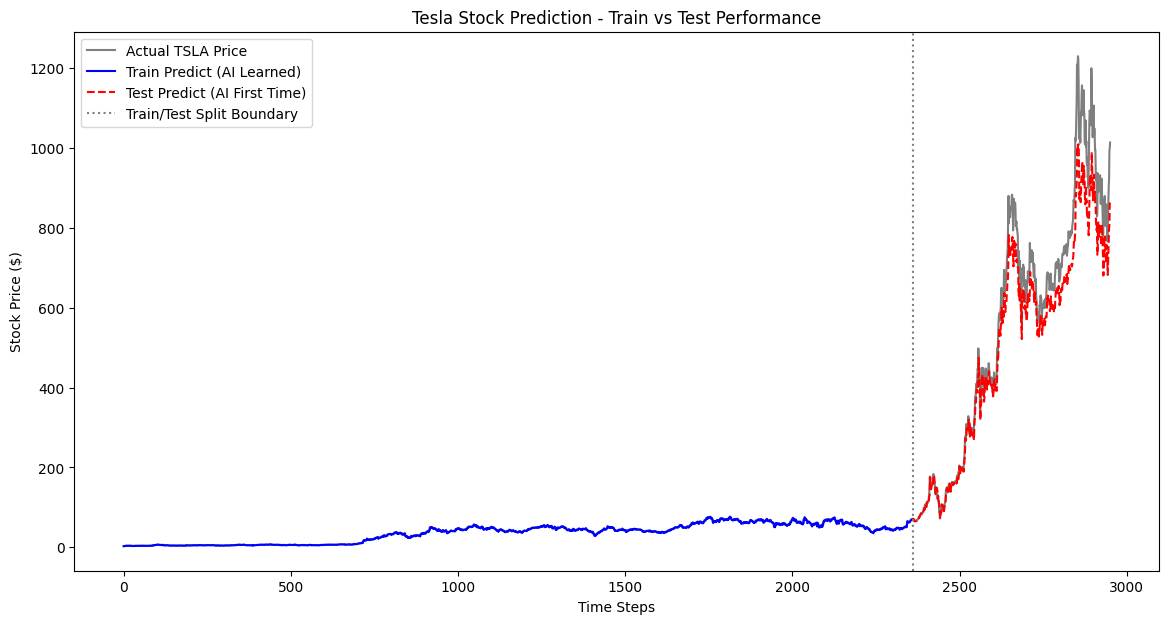

In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt

# 1. 테슬라 주가 CSV 파일 로드
file_path = '/content/drive/MyDrive/Colab Notebooks/TSLA.csv'
df = pd.read_csv(file_path)
tesla_raw_data = df['Close'].values.reshape(-1, 1)

# 2. 데이터 전처리 (0~1 사이로 정규화)
scaler = MinMaxScaler(feature_range=(0, 1))
tesla_scaled_data = scaler.fit_transform(tesla_raw_data)

# 3. 데이터 묶기 함수 (과거 5일 데이터를 보고 다음 날 예측)
def make_tesla_sample(data, days_to_look):
    train = []
    target = []
    for i in range(len(data) - days_to_look):
        train.append(data[i:i+days_to_look])
        target.append(data[i+days_to_look])
    return np.array(train), np.array(target)

TESLA_DAYS = 5
X, y = make_tesla_sample(tesla_scaled_data, TESLA_DAYS)

# ---------------------------------------------------------
# [핵심] 4. 훈련 데이터와 테스트 데이터 분리 (순서 유지)
# 전체 데이터 중 앞의 80%는 학습에 쓰고, 뒤의 20%는 테스트에 씁니다.
split_index = int(len(X) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]
# ---------------------------------------------------------

# 5. SimpleRNN 모델 설계 및 학습 (오직 훈련 데이터만 사용)
model = Sequential()
model.add(SimpleRNN(16, activation='tanh', input_shape=(TESLA_DAYS, 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
# X_train과 y_train으로만 학습을 진행합니다.
history = model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)

# 6. 예측 수행 (훈련 데이터 예측 vs 테스트 데이터 예측)
train_predict = model.predict(X_train)
test_predict = model.predict(X_test) # AI가 평생 보지 못한 미래의 데이터

# 7. 원래 주가($) 단위로 복원
train_predict_prices = scaler.inverse_transform(train_predict)
test_predict_prices = scaler.inverse_transform(test_predict)
actual_prices = scaler.inverse_transform(y)

# 8. 최종 결과 시각화 (학습 영역과 테스트 영역 분리 표시)
plt.figure(figsize=(14, 7))

# 실제 전체 주가 그래프 (검은색)
plt.plot(actual_prices, label="Actual TSLA Price", color='black', alpha=0.5)

# 학습 데이터 구간의 예측 결과 (파란색)
# 원래 인덱스 위치에 맞춰 그리기 위해 빈 배열(NaN)을 채워 넣습니다.
train_plot = np.empty_like(actual_prices)
train_plot[:, :] = np.nan
train_plot[0:len(train_predict_prices)] = train_predict_prices
plt.plot(train_plot, label="Train Predict (AI Learned)", color='blue')

# [결과 변동성 확인 지점] 테스트 데이터 구간의 예측 결과 (빨간색)
test_plot = np.empty_like(actual_prices)
test_plot[:, :] = np.nan
test_plot[len(train_predict_prices):len(actual_prices)] = test_predict_prices
plt.plot(test_plot, label="Test Predict (AI First Time)", color='red', linestyle='--')

# 학습과 테스트 경계선 표시
plt.axvline(x=split_index, color='gray', linestyle=':', label='Train/Test Split Boundary')

plt.title("Tesla Stock Prediction - Train vs Test Performance")
plt.xlabel("Time Steps")
plt.ylabel("Stock Price ($)")
plt.legend()
plt.show()

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0036
Epoch 2/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.4082e-04
Epoch 3/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.6593e-04
Epoch 4/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.5533e-04
Epoch 5/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.8975e-04
Epoch 6/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.6612e-04
Epoch 7/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.5145e-04
Epoch 8/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2211e-04
Epoch 9/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.1169e-04
Epoch 10/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0715e-04
Epoch 11/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0569e-04
Epoch 12/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0285e-04
Epoch 13/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.3342e-05
Epoch 14/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.8677e-05
Epoch 15/50
172/

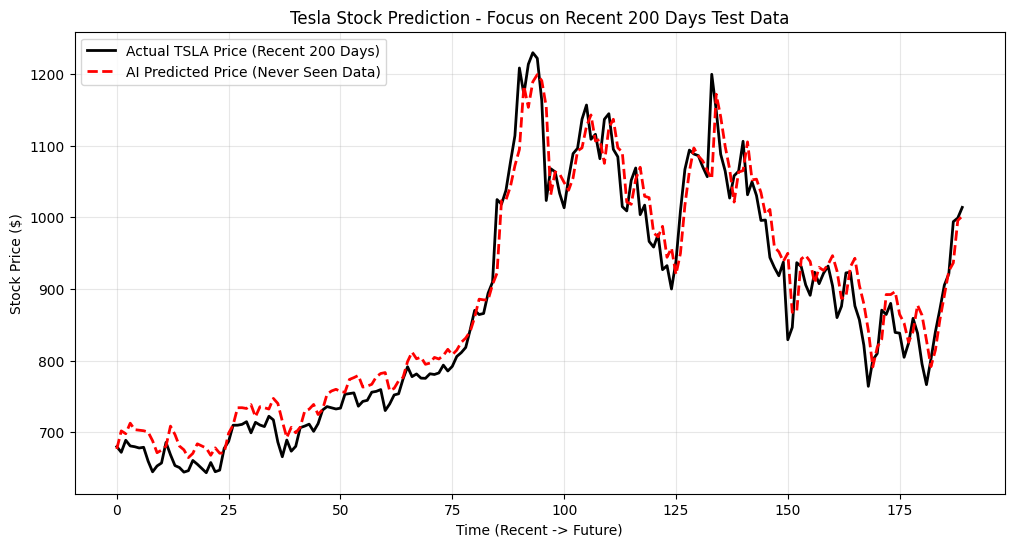

In [5]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt

# 1. 테슬라 주가 데이터 로드 및 종가 추출
file_path = '/content/drive/MyDrive/Colab Notebooks/TSLA.csv'
df = pd.read_csv(file_path)
tesla_raw_data = df['Close'].values.reshape(-1, 1)

# 2. 데이터 전처리 (0~1 정규화)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(tesla_raw_data)

# ---------------------------------------------------------
# [사용자 요청 반영] 3. 최근 200일을 테스트 데이터로 분리
TEST_SIZE = 200
train_data = scaled[:-TEST_SIZE]  # 마지막 200일을 제외한 과거 전체 데이터
test_data = scaled[-TEST_SIZE:]   # 오직 마지막 최근 200일 데이터
# ---------------------------------------------------------

# 4. 시계열 샘플(X, y) 생성 함수
def make_tesla_sample(data, days_to_look):
    train = []
    target = []
    for i in range(len(data) - days_to_look):
        train.append(data[i:i+days_to_look])
        target.append(data[i+days_to_look])
    return np.array(train), np.array(target)

TESLA_DAYS = 10

# 훈련 데이터와 테스트 데이터를 각각 독립적으로 묶어줍니다.
X_train, y_train = make_tesla_sample(train_data, TESLA_DAYS)
X_test, y_test = make_tesla_sample(test_data, TESLA_DAYS)

# 5. SimpleRNN 모델 설계 및 훈련 (오직 과거 훈련 데이터로만 학습)
model = Sequential()
model.add(SimpleRNN(16, activation='tanh', input_shape=(TESLA_DAYS, 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
# 은닉층 학습을 진행합니다.
history = model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)

# 6. 예측 수행 (AI가 배운 데이터 vs 처음 보는 최근 200일 데이터)
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# 7. 실제 주가($) 단위로 복원 (시각화용)
train_predict_prices = scaler.inverse_transform(train_predict)
test_predict_prices = scaler.inverse_transform(test_predict)

# 실제 정답 가격 복원
actual_train_prices = scaler.inverse_transform(y_train)
actual_test_prices = scaler.inverse_transform(y_test)

# 8. 최근 200일 테스트 데이터 구간의 "매우 다른 결과" 집중 시각화
plt.figure(figsize=(12, 6))

# 실제 주가 (검은색)
plt.plot(actual_test_prices, label="Actual TSLA Price (Recent 200 Days)", color='black', linewidth=2)

# AI의 예측 주가 (빨간색 점선)
plt.plot(test_predict_prices, label="AI Predicted Price (Never Seen Data)", color='red', linestyle='--', linewidth=2)

plt.title("Tesla Stock Prediction - Focus on Recent 200 Days Test Data")
plt.xlabel("Time (Recent -> Future)")
plt.ylabel("Stock Price ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0037
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.6589e-04
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.8975e-04
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5793e-04
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2517e-04
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1615e-04
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.9459e-05
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.5662e-05
Epoch 9/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.7357e-05
Epoch 10/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.6502e-05
Epoch 11/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.4991e-05
Epoch 12/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.2209e-05
Epoch 13/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.0977e-05
Epoch 14/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.7706e-05
Epoch 15/100
86/86 ━━━━━━━━━━━━

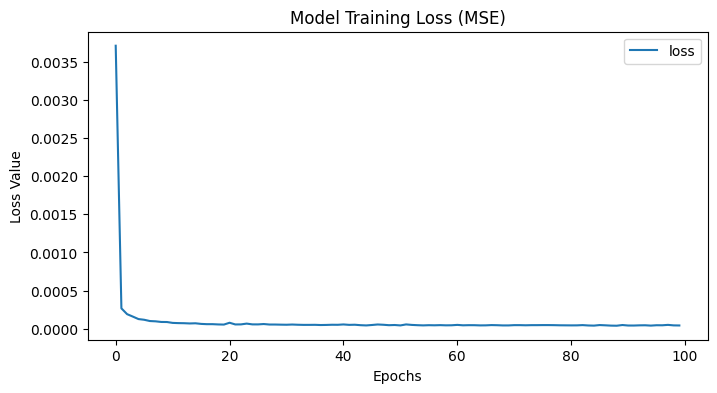

86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


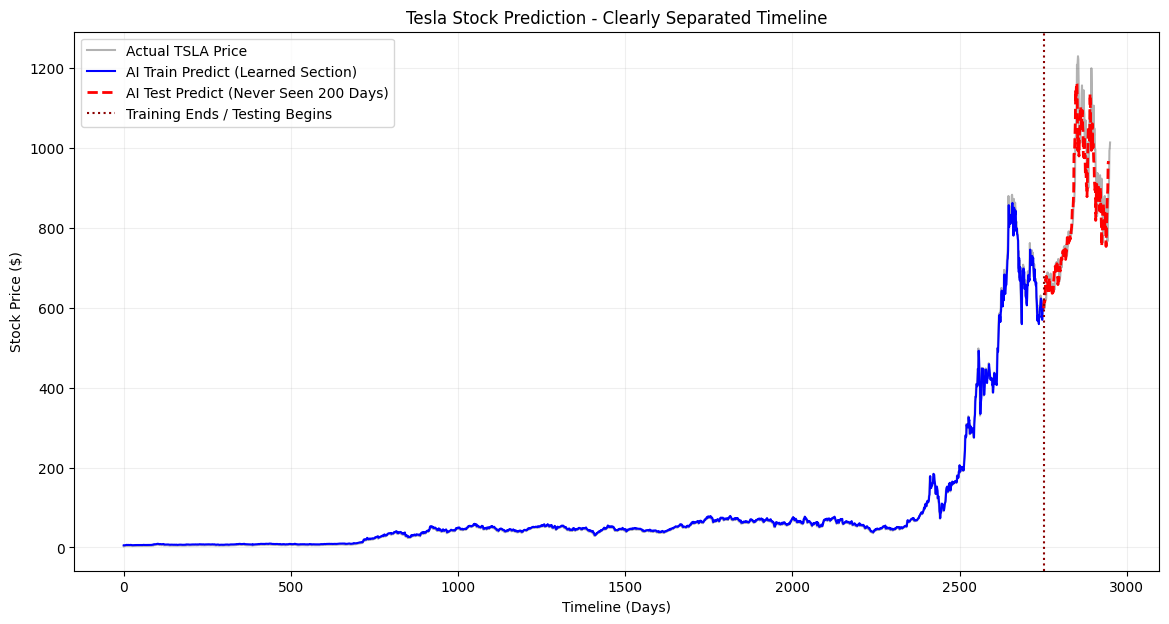

In [7]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt

# 1. 테슬라 주가 데이터 로드
file_path = '/content/drive/MyDrive/Colab Notebooks/TSLA.csv'
df = pd.read_csv(file_path)
tesla_raw_data = df['Close'].values.reshape(-1, 1)

# 2. 데이터 전처리 (0~1 정규화)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(tesla_raw_data)

# 3. 최근 200일을 테스트 데이터로 분리
TEST_SIZE = 200
train_data = scaled[:-TEST_SIZE]
test_data = scaled[-TEST_SIZE:]

# 4. 시계열 샘플 생성 함수
def make_tesla_sample(data, days_to_look):
    train = []
    target = []
    for i in range(len(data) - days_to_look):
        train.append(data[i:i+days_to_look])
        target.append(data[i+days_to_look])
    return np.array(train), np.array(target)

TESLA_DAYS = 5
X_train, y_train = make_tesla_sample(train_data, TESLA_DAYS)
X_test, y_test = make_tesla_sample(test_data, TESLA_DAYS)

# 5. SimpleRNN 모델 구성
model = Sequential()
model.add(SimpleRNN(16, activation='tanh', input_shape=(TESLA_DAYS, 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

# [사용자 요청 반영] 6. 모델 학습 및 Loss 그래프 출력
# 전체 데이터를 다 묶은 X, y 대신 분리된 X_train, y_train을 넣어 학습 효율을 지킵니다.
history = model.fit(X_train, y_train, epochs=100, verbose=1)

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label="loss")
plt.title("Model Training Loss (MSE)")
plt.xlabel("Epochs")
plt.ylabel("Loss Value")
plt.legend()
plt.show()

# 7. 예측 수행 및 원래 달러 가격($) 복원
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

train_predict_prices = scaler.inverse_transform(train_predict)
test_predict_prices = scaler.inverse_transform(test_predict)
actual_prices = scaler.inverse_transform(scaled[TESLA_DAYS:]) # 윈도우 크기 제외한 실제 전체 가격

# 8. [헷갈리지 않게 개선] 시간 순서대로 정렬하여 분리 시각화
plt.figure(figsize=(14, 7))

# ① 실제 전체 주가 배경 그리기 (투명한 검은색)
plt.plot(actual_prices, label="Actual TSLA Price", color='black', alpha=0.3)

# ② AI가 공부한 '과거 훈련 구간' 예측 (파란색 선)
# 0번 인덱스부터 학습 종료 시점까지만 채워서 플로팅합니다.
train_plot = np.empty_like(actual_prices)
train_plot[:, :] = np.nan
train_plot[0:len(train_predict_prices)] = train_predict_prices
plt.plot(train_plot, label="AI Train Predict (Learned Section)", color='blue', linewidth=1.5)

# ③ [핵심 변형] AI가 처음 보는 '최근 200일 미래 구간' 예측 (빨간색 점선)
# 훈련 구간이 끝난 바로 다음 인덱스부터 배열 끝까지 위치를 뒤로 밀어서 배치합니다.
test_plot = np.empty_like(actual_prices)
test_plot[:, :] = np.nan
start_idx = len(train_predict_prices)
end_idx = start_idx + len(test_predict_prices)
test_plot[start_idx:end_idx] = test_predict_prices
plt.plot(test_plot, label="AI Test Predict (Never Seen 200 Days)", color='red', linestyle='--', linewidth=2)

# 두 구간을 명확히 갈라주는 수직 경계선
plt.axvline(x=start_idx, color='darkred', linestyle=':', label='Training Ends / Testing Begins')

plt.title("Tesla Stock Prediction - Clearly Separated Timeline")
plt.xlabel("Timeline (Days)")
plt.ylabel("Stock Price ($)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()